# testAnt Report Card — Interactive Explorer

Each plot from the one-page PDF report card in its own cell for interactive tinkering.

**Data**: Either the full summary CSVs or the decimated `_notebook.tar.gz` bundle.
- Full summaries: `summarize_for_report.py` output (sky.csv, ticc.csv, timtp.csv)
- Notebook bundle: `pack_for_notebook.py` output (sky_5min.csv, timing_1hz.csv, adev_windowed.csv)

In [17]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from report_plots import (
    VERSION, MINIMUM_HOURS, CMAP, METRICS, FIXED_Y, FIXED_X_HOURS,
    SERIES_KEYS, SERIES_YLABELS, CNO_VMIN, CNO_VMAX, SLIP_PCT_MAX,
    CONSTELLATIONS, R_EARTH,
    fraction, fmt_val, simple_formatter, apply_fixed_y,
    compute_lock_loss, plot_sparkline,
    polar_cno_heatmap, setup_polar_ax, theoretical_sky_mask,
)

try:
    import allantools
    HAS_ALLAN = True
except ImportError:
    HAS_ALLAN = False
    print("allantools not installed — ADEV cells will use pre-computed data")

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4)

## Configuration

Edit this cell to point at your data.

In [ ]:
# ── Data paths ─────────────────────────────────────────────
TAG = "patch3-bot_patch2-top_20260310T211636"
DATA_DIR = "../data/patch3_25h"

# Which receiver channel to analyse
RX = "BOT"   # BOT = Patch3, TOP = Patch2

# Report metadata
ANTENNA = "Patch3"
MOUNT = "East roof slope"
RECEIVER = "u-blox ZED-F9T"

# Observer latitude (for theoretical sky coverage)
OBS_LAT = 41.843   # degrees north

# ── File resolution ───────────────────────────────────────
# Try notebook bundle first (decimated), fall back to full summaries
import os

snr_path   = f"{DATA_DIR}/{TAG}_snr_1min.csv"
rawx_path  = f"{DATA_DIR}/{TAG}_rawx_1min.csv"
slips_path = f"{DATA_DIR}/{TAG}_slips.csv"

# Sky: prefer 5-min decimated, fall back to full 1-min
sky_5min = f"{DATA_DIR}/{TAG}_sky_5min.csv"
sky_1min = f"{DATA_DIR}/{TAG}_sky.csv"
sky_path = sky_5min if os.path.exists(sky_5min) else sky_1min

# Timing: prefer pre-computed, fall back to raw ticc+timtp
timing_path = f"{DATA_DIR}/{TAG}_timing_1hz.csv"
adev_path   = f"{DATA_DIR}/{TAG}_adev_windowed.csv"
ticc_path   = f"{DATA_DIR}/{TAG}_ticc.csv"
timtp_path  = f"{DATA_DIR}/{TAG}_timtp.csv"
USE_PRECOMPUTED = os.path.exists(timing_path)

print(f"Sky data:    {os.path.basename(sky_path)}")
print(f"Timing mode: {'pre-computed' if USE_PRECOMPUTED else 'raw ticc+timtp'}")
print(f"Observer:    {OBS_LAT:.3f}° N")

## Load data

In [19]:
# ── SNR ────────────────────────────────────────────────────
snr = pd.read_csv(snr_path, parse_dates=["minute"])
snr["minute"] = pd.to_datetime(snr["minute"], utc=True)
snr_rx = snr[snr["receiver"] == RX].sort_values("minute").reset_index(drop=True)
t0 = snr_rx["minute"].iloc[0]
snr_rx["hours"] = (snr_rx["minute"] - t0).dt.total_seconds() / 3600
total_hours = (snr_rx["minute"].iloc[-1] - t0 + pd.Timedelta(minutes=1)).total_seconds() / 3600

# ── RAWX / CMC ────────────────────────────────────────────
rawx = pd.read_csv(rawx_path, parse_dates=["minute"])
rawx["minute"] = pd.to_datetime(rawx["minute"], utc=True)
rawx_rx = rawx[rawx["receiver"] == RX].sort_values("minute").reset_index(drop=True)
rawx_rx["hours"] = (rawx_rx["minute"] - t0).dt.total_seconds() / 3600

# ── Sky ────────────────────────────────────────────────────
sky = pd.read_csv(sky_path, parse_dates=["minute"])
sky["minute"] = pd.to_datetime(sky["minute"], utc=True)
sky_rx = sky[sky["receiver"] == RX].copy()

# ── Slips ─────────────────────────────────────────────────
slips_rx = pd.DataFrame()
if os.path.exists(slips_path):
    sl = pd.read_csv(slips_path, parse_dates=["timestamp"])
    sl["timestamp"] = pd.to_datetime(sl["timestamp"], utc=True)
    slips_rx = sl[sl["receiver"] == RX].copy()
    slips_rx["hours"] = (slips_rx["timestamp"] - t0).dt.total_seconds() / 3600

# ── Timing / ADEV ─────────────────────────────────────────
if USE_PRECOMPUTED:
    timing = pd.read_csv(timing_path)
    if "utc_s" in timing.columns:
        timing["utc_s"] = pd.to_datetime(timing["utc_s"], utc=True)
        timing["hours"] = (timing["utc_s"] - t0).dt.total_seconds() / 3600
    else:
        timing["hours"] = np.arange(len(timing)) / 3600
    adev_pre = pd.read_csv(adev_path)
else:
    # Compute from raw ticc + timtp (same logic as report_card.py)
    ticc = pd.read_csv(ticc_path)
    has_host_ts = "host_timestamp" in ticc.columns
    if has_host_ts:
        ticc["host_timestamp"] = pd.to_datetime(ticc["host_timestamp"], utc=True)
        ticc["utc_s"] = ticc["host_timestamp"].dt.floor("s")
        cha = ticc[ticc["channel"] == "chA"].groupby("utc_s").first().reset_index()
        chb = ticc[ticc["channel"] == "chB"].groupby("utc_s").first().reset_index()
        pairs = cha.merge(chb, on="utc_s", suffixes=("_a", "_b"))
        pairs["diff_ps"] = (
            pairs["ref_sec_a"].astype(np.int64) * 1_000_000_000_000
            + pairs["ref_ps_a"].astype(np.int64)
            - pairs["ref_sec_b"].astype(np.int64) * 1_000_000_000_000
            - pairs["ref_ps_b"].astype(np.int64)
        )
    else:
        ticc["ts_ps"] = (ticc["timestamp_s"] * 1e12).round().astype(np.int64)
        cha = ticc[ticc["channel"] == "chA"].reset_index(drop=True)
        chb = ticc[ticc["channel"] == "chB"].reset_index(drop=True)
        n = min(len(cha), len(chb))
        cha, chb = cha.iloc[:n], chb.iloc[:n]
        pairs = pd.DataFrame({"diff_ps": cha["ts_ps"].values - chb["ts_ps"].values})
        timtp_tmp = pd.read_csv(timtp_path, parse_dates=["timestamp"])
        timtp_top = timtp_tmp[timtp_tmp["receiver"] == "TOP"].sort_values("timestamp")
        if len(timtp_top) >= n:
            pairs["utc_s"] = timtp_top["timestamp"].iloc[:n].dt.floor("s").values

    pairs["diff_ns"] = pairs["diff_ps"] / 1000.0

    timtp = pd.read_csv(timtp_path, parse_dates=["timestamp"])
    timtp["utc_s"] = timtp["timestamp"].dt.floor("s")
    if "utc_s" in pairs.columns:
        pairs["utc_s"] = pd.to_datetime(pairs["utc_s"], utc=True)
        for label in ["TOP", "BOT"]:
            q = timtp[timtp["receiver"] == label][["utc_s", "qerr_ps"]].copy()
            q["utc_s"] = q["utc_s"] + pd.Timedelta(seconds=1)
            q = q.rename(columns={"qerr_ps": f"qerr_{label.lower()}"})
            pairs = pairs.merge(q, on="utc_s", how="left")
        pairs = pairs.dropna(subset=["qerr_top", "qerr_bot"])
        corr_p = pairs["diff_ns"] + (pairs["qerr_top"] - pairs["qerr_bot"]) / 1000
        corr_m = pairs["diff_ns"] - (pairs["qerr_top"] - pairs["qerr_bot"]) / 1000
        pairs["corr_ns"] = corr_p if corr_p.std() < corr_m.std() else corr_m
    else:
        pairs["corr_ns"] = pairs["diff_ns"]

    med = pairs["corr_ns"].median()
    mad = (pairs["corr_ns"] - med).abs().median() * 1.4826
    pairs = pairs[(pairs["corr_ns"] - med).abs() < max(mad * 5, 50)].reset_index(drop=True)

    if "utc_s" in pairs.columns:
        pairs["hours"] = (pairs["utc_s"] - t0).dt.total_seconds() / 3600
    else:
        pairs["hours"] = np.arange(len(pairs)) / 3600

    timing = pairs[["hours", "diff_ns", "corr_ns"]].copy()
    adev_pre = None  # compute on demand below

print(f"SNR:   {len(snr_rx)} rows, {total_hours:.1f} h")
print(f"RAWX:  {len(rawx_rx)} rows")
print(f"Sky:   {len(sky_rx)} rows")
print(f"Slips: {len(slips_rx)} rows")
print(f"Timing: {len(timing)} corrected pairs")

SNR:   1501 rows, 25.0 h
RAWX:  1501 rows
Sky:   36672 rows
Slips: 5500 rows
Timing: 89999 corrected pairs


## Shared plot config

Colormap, axis ranges, helpers — edit these to change all plots at once.

In [20]:
# Heatmap grid resolution (degrees) — used by inline polar plot cells
AZ_BIN_DEG = 10
EL_BIN_DEG = 5
MIN_SAMPLES_PER_BIN = 3

print(f"report_plots v{VERSION} loaded — {len(METRICS)} metrics, "
      f"{len(CONSTELLATIONS)} constellations")

report_plots v0.3.0 loaded — 5 metrics, 4 constellations


---
## 1. C/N0 sparkline

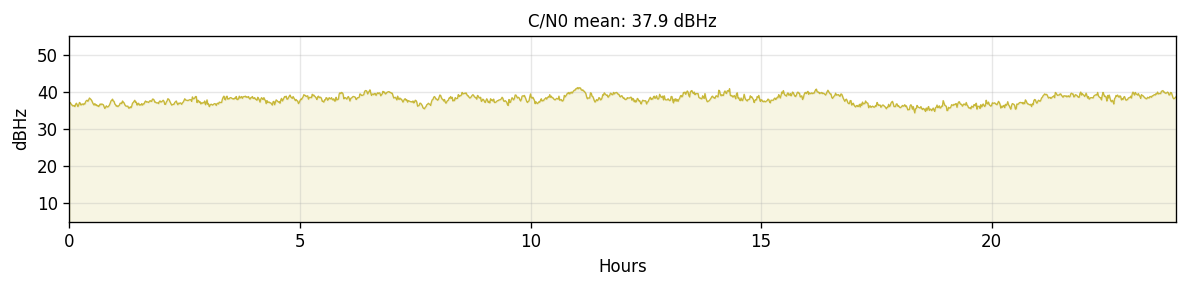

In [21]:
fig, ax = plt.subplots(figsize=(10, 2.5))
t = snr_rx["hours"].values
v = snr_rx["mean_cno"].values
frac = fraction(np.mean(v), 25, 50, False)
color = CMAP(frac)

ax.plot(t, v, color=color, lw=0.8, alpha=0.85)
ax.fill_between(t, v, alpha=0.12, color=color)
apply_fixed_y(ax, "cno")
ax.set_xlim(0, FIXED_X_HOURS)
ax.set_ylabel("dBHz")
ax.set_xlabel("Hours")
ax.set_title(f"C/N0 mean: {np.mean(v):.1f} dBHz", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Multipath (CMC) sparkline

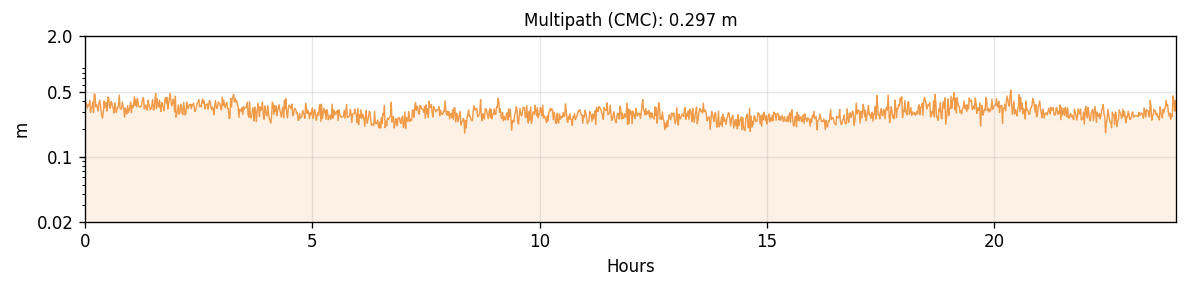

In [22]:
fig, ax = plt.subplots(figsize=(10, 2.5))
t = rawx_rx["hours"].values
v = rawx_rx["cmc_std_m"].values
frac = fraction(np.median(v), 1.0, 0.03, True)
color = CMAP(frac)

ax.plot(t, v, color=color, lw=0.8, alpha=0.85)
ax.fill_between(t, v, alpha=0.12, color=color)
apply_fixed_y(ax, "cmc")
ax.set_xlim(0, FIXED_X_HOURS)
ax.set_ylabel("m")
ax.set_xlabel("Hours")
ax.set_title(f"Multipath (CMC): {np.median(v):.3f} m", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. ADEV sparkline

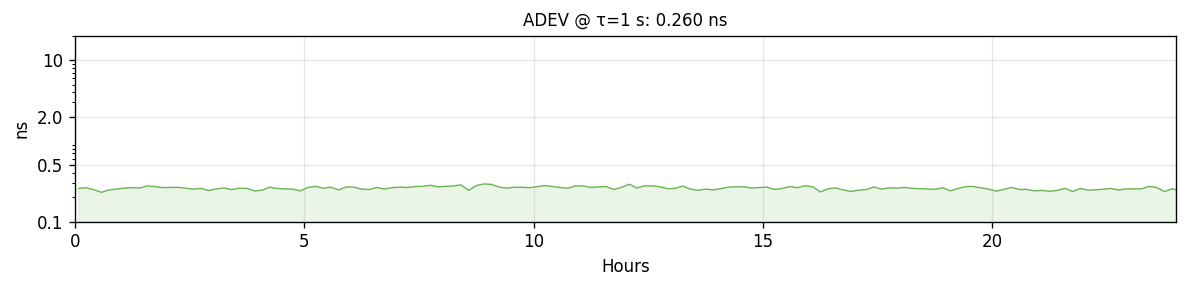

In [23]:
# Compute windowed ADEV from timing data
if adev_pre is not None and len(adev_pre) > 0:
    # Use pre-computed windowed ADEV
    aw = adev_pre[adev_pre["tau"] == 1]
    windowed = aw[aw["window_h"] >= 0]
    adev_t = windowed["window_h"].values
    adev_v = windowed["adev_ns"].values
    overall = aw[aw["window_h"] < 0]
    adev_overall = overall["adev_ns"].values[0] if len(overall) else np.mean(adev_v)
elif HAS_ALLAN:
    freq_ns = timing["corr_ns"].values - timing["corr_ns"].mean()
    timing["window"] = (timing["hours"] * 6).astype(int)
    adev_series = []
    for _, g in timing.groupby("window"):
        if len(g) < 60:
            continue
        y = g["corr_ns"].values - g["corr_ns"].mean()
        _, ad, _, _ = allantools.adev(y, rate=1.0, data_type="freq", taus=[1])
        if len(ad):
            adev_series.append((g["hours"].mean(), ad[0]))
    adev_t = np.array([a[0] for a in adev_series])
    adev_v = np.array([a[1] for a in adev_series])
    _, ad_all, _, _ = allantools.adev(freq_ns, rate=1.0, data_type="freq", taus=[1])
    adev_overall = ad_all[0] if len(ad_all) else np.mean(adev_v)
else:
    print("No ADEV data available")
    adev_t, adev_v, adev_overall = np.array([]), np.array([]), 0

if len(adev_t) > 0:
    fig, ax = plt.subplots(figsize=(10, 2.5))
    frac = fraction(adev_overall, 10, 0.1, True)
    color = CMAP(frac)
    ax.plot(adev_t, adev_v, color=color, lw=0.8, alpha=0.85)
    ax.fill_between(adev_t, adev_v, alpha=0.12, color=color)
    apply_fixed_y(ax, "adev")
    ax.set_xlim(0, FIXED_X_HOURS)
    ax.set_ylabel("ns")
    ax.set_xlabel("Hours")
    ax.set_title(f"ADEV @ τ=1 s: {adev_overall:.3f} ns", fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. Carrier lock loss sparkline

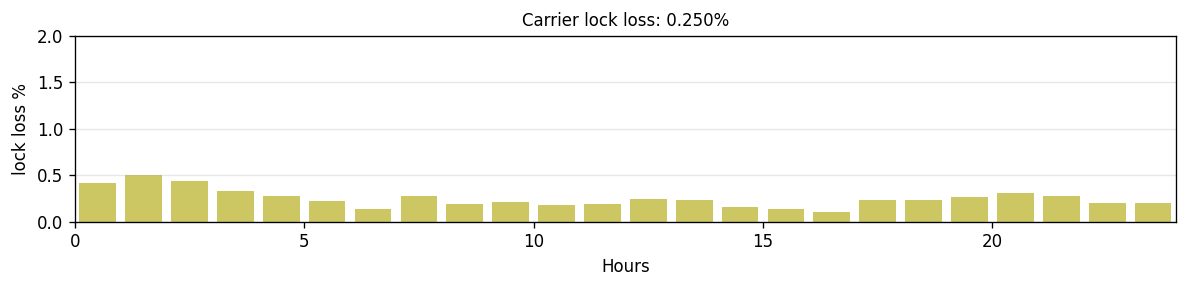

In [24]:
# Compute lock loss % per hour using sky exposure
slips_hours = np.array([])
sky_hours = np.array([])

if len(sky_rx) > 0:
    sky_hours = (sky_rx["minute"] - t0).dt.total_seconds().values / 3600
if len(slips_rx) > 0:
    slips_hours = slips_rx["hours"].values

t_centers, loss_pct, overall_pct = compute_lock_loss(slips_hours, sky_hours, total_hours)

fig, ax = plt.subplots(figsize=(10, 2.5))
frac = fraction(overall_pct, 10, 0.01, True)
color = CMAP(frac)
ax.bar(t_centers, loss_pct, width=0.8, color=color, alpha=0.7, ec="none")
apply_fixed_y(ax, "lockloss")
ax.set_xlim(0, FIXED_X_HOURS)
ax.set_ylabel("lock loss %")
ax.set_xlabel("Hours")
ax.set_title(f"Carrier lock loss: {overall_pct:.3f}%", fontsize=10)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Satellite count sparkline

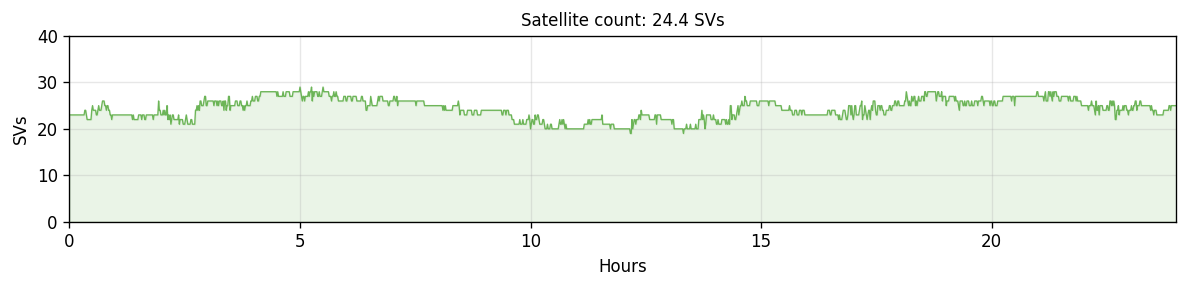

In [9]:
fig, ax = plt.subplots(figsize=(10, 2.5))
t = snr_rx["hours"].values
v = snr_rx["sat_count"].values.astype(float)
frac = fraction(np.mean(v), 4, 30, False)
color = CMAP(frac)

ax.plot(t, v, color=color, lw=0.8, alpha=0.85)
ax.fill_between(t, v, alpha=0.12, color=color)
apply_fixed_y(ax, "satcount")
ax.set_xlim(0, FIXED_X_HOURS)
ax.set_ylabel("SVs")
ax.set_xlabel("Hours")
ax.set_title(f"Satellite count: {np.mean(v):.1f} SVs", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Polar C/N0 heatmap

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
setup_polar_ax(ax)
ax.set_title(f"Sky C/N0 heatmap — {ANTENNA}", fontsize=11, pad=15)

azim = sky_rx["azim_deg"].values
elev = sky_rx["elev_deg"].values
cno = sky_rx["cno_dBHz"].values

pc, grid = polar_cno_heatmap(ax, azim, elev, cno,
                              az_bin=AZ_BIN_DEG, el_bin=EL_BIN_DEG,
                              min_samples=MIN_SAMPLES_PER_BIN)

# Slip overlay
if len(slips_rx) > 0 and len(sky_rx) > 0:
    slips_rx_m = slips_rx.copy()
    slips_rx_m["minute"] = slips_rx_m["timestamp"].dt.floor("min")
    merged = slips_rx_m.merge(sky_rx, on=["minute", "sv_id"], how="left",
                              suffixes=("", "_sky"))
    merged = merged.dropna(subset=["elev_deg", "azim_deg"])
    if len(merged) > 0:
        ax.scatter(np.radians(merged["azim_deg"]), 90 - merged["elev_deg"],
                   c="red", s=8, marker="x", linewidths=0.5, alpha=0.5,
                   zorder=5, label="Lock loss")
        ax.legend(fontsize=8, loc="lower left", bbox_to_anchor=(-0.05, -0.08))

plt.colorbar(pc, ax=ax, shrink=0.6, pad=0.08, label="C/N0 (dBHz)")
plt.tight_layout()
plt.show()

## 6b. Theoretical sky coverage

Shows where GNSS satellites *can* appear from this latitude, based on orbital
mechanics alone. The "north hole" is physical — no satellite with inclination
55° can reach that part of the sky from 42°N. Grey cells = no satellite ever
appears there. This is the baseline: any gap in actual observations that falls
inside the grey zone is NOT an antenna or site defect.

Left: combined GPS+GAL+BDS coverage mask.  Right: per-constellation max elevation.

In [ ]:
# Compute theoretical sky masks for each constellation
masks = {}
max_els = {}
for name, incl, alt in CONSTELLATIONS:
    az_c, mel, az_bins, el_bins, msk = theoretical_sky_mask(OBS_LAT, incl, alt)
    masks[name] = msk
    max_els[name] = (az_c, mel)

# Combined mask (any constellation can reach this cell)
combined = np.zeros_like(list(masks.values())[0], dtype=bool)
for msk in masks.values():
    combined |= msk

# ── Plot 1: Combined coverage mask overlaid on observed heatmap ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                subplot_kw={"projection": "polar"})

for ax in (ax1, ax2):
    setup_polar_ax(ax)

# Left: observed C/N0 heatmap + theoretical boundary
ax1.set_title(f"Observed C/N0 + theoretical boundary\n{OBS_LAT:.1f}°N", fontsize=10, pad=12)
polar_cno_heatmap(ax1, azim, elev, cno,
                  az_bin=AZ_BIN_DEG, el_bin=EL_BIN_DEG,
                  min_samples=MIN_SAMPLES_PER_BIN)

# Overlay theoretical boundary as a red dashed line (max elevation per azimuth)
az_c_gps, mel_gps = max_els["GPS"]
valid = np.isfinite(mel_gps)
boundary_r = 90 - mel_gps[valid]
boundary_az = np.radians(az_c_gps[valid])
boundary_az = np.append(boundary_az, boundary_az[0])
boundary_r = np.append(boundary_r, boundary_r[0])
ax1.plot(boundary_az, boundary_r, 'r--', lw=1.5, alpha=0.8, label="GPS max el.")

az_c_glo, mel_glo = max_els["GLONASS"]
valid_g = np.isfinite(mel_glo)
br_glo = 90 - mel_glo[valid_g]
ba_glo = np.radians(az_c_glo[valid_g])
ba_glo = np.append(ba_glo, ba_glo[0])
br_glo = np.append(br_glo, br_glo[0])
ax1.plot(ba_glo, br_glo, 'b:', lw=1.2, alpha=0.7, label="GLONASS max el.")

ax1.legend(fontsize=7, loc="lower left", bbox_to_anchor=(-0.08, -0.12))

# Right: per-constellation max elevation vs azimuth (polar line plot)
ax2.set_title(f"Max elevation by constellation\n{OBS_LAT:.1f}°N", fontsize=10, pad=12)

colors_c = {"GPS": "#2266aa", "Galileo": "#cc6622", "BDS MEO": "#22aa66", "GLONASS": "#aa2266"}
for name, incl, alt in CONSTELLATIONS:
    az_c, mel = max_els[name]
    valid = np.isfinite(mel)
    r = 90 - mel[valid]
    a = np.radians(az_c[valid])
    a = np.append(a, a[0])
    r = np.append(r, r[0])
    ax2.plot(a, r, lw=1.5, color=colors_c[name], label=f"{name} ({incl:.0f}°)")
    ax2.fill(a, r, alpha=0.05, color=colors_c[name])

ax2.set_facecolor("#f0f0f0")
ax2.legend(fontsize=7, loc="lower left", bbox_to_anchor=(-0.08, -0.12))

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTheoretical sky coverage at {OBS_LAT:.1f}°N:")
for name, incl, alt in CONSTELLATIONS:
    az_c, mel = max_els[name]
    north_max = mel[np.argmin(np.abs(az_c - 0))]
    south_max = mel[np.argmin(np.abs(az_c - 180))]
    print(f"  {name:10s} (i={incl:4.1f}°): max el. due north = {north_max:.1f}°, "
          f"due south = {south_max:.1f}°")

## 7. C/N0 & lock loss vs elevation

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

bins = np.arange(0, 95, 5)
bin_centers = bins[:-1] + 2.5

cno_means = []
cno_stds = []
for b in range(len(bins) - 1):
    mask = (sky_rx["elev_deg"] >= bins[b]) & (sky_rx["elev_deg"] < bins[b + 1])
    vals = sky_rx.loc[mask, "cno_dBHz"]
    cno_means.append(vals.mean() if len(vals) > 10 else np.nan)
    cno_stds.append(vals.std() if len(vals) > 10 else np.nan)
cno_means = np.array(cno_means)
cno_stds = np.array(cno_stds)

ax1.fill_between(bin_centers, cno_means - cno_stds, cno_means + cno_stds,
                 alpha=0.2, color="#4488cc")
ax1.plot(bin_centers, cno_means, "o-", color="#4488cc", markersize=4, lw=1.5,
         label="C/N0")
ax1.set_xlabel("Elevation (°)", fontsize=10)
ax1.set_ylabel("C/N0 (dBHz)", fontsize=10, color="#4488cc")
ax1.set_xlim(0, 90)
ax1.grid(True, axis="y", alpha=0.3)

# Lock loss overlay
if len(slips_rx) > 0:
    slips_rx_m = slips_rx.copy()
    slips_rx_m["minute"] = slips_rx_m["timestamp"].dt.floor("min")
    merged = slips_rx_m.merge(sky_rx, on=["minute", "sv_id"], how="left",
                              suffixes=("", "_sky"))
    merged = merged.dropna(subset=["elev_deg", "azim_deg"])
    if len(merged) > 0:
        slip_counts, _ = np.histogram(merged["elev_deg"].values, bins=bins)
        # Each sky row = 1 sat-minute = 60 sat-seconds of exposure
        exposure_satsec, _ = np.histogram(sky_rx["elev_deg"].values, bins=bins)
        exposure_satsec = exposure_satsec * 60.0
        with np.errstate(divide="ignore", invalid="ignore"):
            loss_pct = np.where(exposure_satsec > 0,
                                slip_counts / exposure_satsec * 100, np.nan)
        ax2 = ax1.twinx()
        ax2.bar(bin_centers, loss_pct, width=4, alpha=0.3, color="red",
                label="Lock loss %")
        ax2.set_ylabel("Lock loss (%)", fontsize=10, color="red")
        ax2.set_ylim(0, SLIP_PCT_MAX)
        ax2.tick_params(colors="red")
        ax2.spines["right"].set_color("red")

ax1.set_title(f"C/N0 & lock loss vs elevation — {ANTENNA}", fontsize=11)
ax1.text(0.0, -0.12, "Horizon", fontsize=9, color="#888",
         ha="left", transform=ax1.transAxes)
ax1.text(1.0, -0.12, "Overhead", fontsize=9, color="#888",
         ha="right", transform=ax1.transAxes)
plt.tight_layout()
plt.show()

## 8. Polar C/N0 residual (deviation from elevation mean)

Shows azimuthal asymmetry: where the antenna/site deviates from its own
elevation-averaged C/N0 profile. Blue = better than average at that elevation,
red = worse. A perfectly symmetric antenna+site would be all grey.

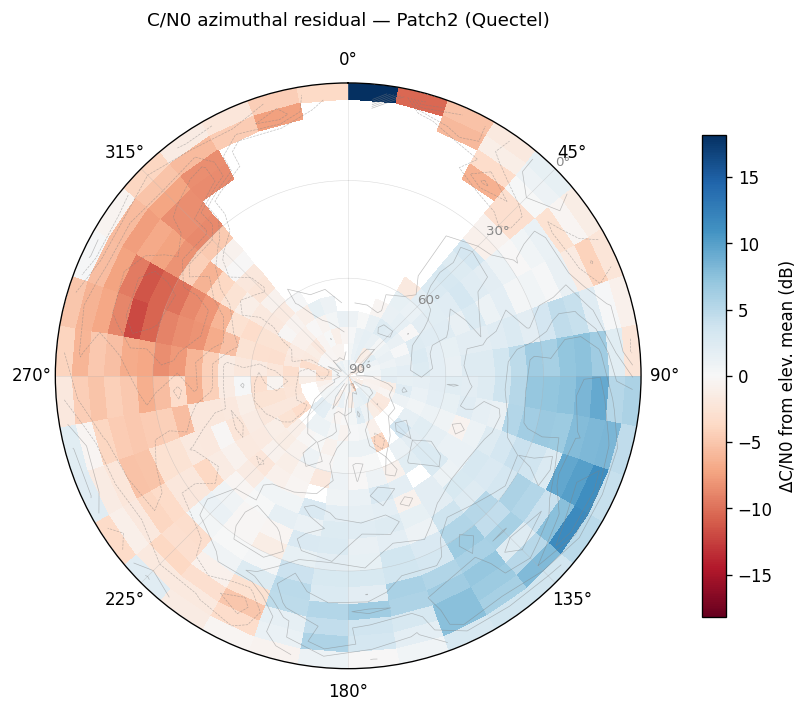

In [13]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_ylim(0, 90)
ax.set_yticks([0, 30, 60, 90])
ax.set_yticklabels(["90°", "60°", "30°", "0°"], fontsize=8, color="#888")
ax.set_rlabel_position(45)
ax.grid(True, linewidth=0.3, alpha=0.5)
ax.set_title(f"C/N0 azimuthal residual — {ANTENNA}", fontsize=11, pad=15)

# Reuse grid from heatmap cell, compute elevation-ring means
az_edges = np.linspace(0, 360, int(360 / AZ_BIN_DEG) + 1)
el_edges = np.linspace(0, 90, int(90 / EL_BIN_DEG) + 1)
grid = np.full((len(el_edges) - 1, len(az_edges) - 1), np.nan)

for i in range(len(el_edges) - 1):
    for j in range(len(az_edges) - 1):
        mask = ((elev >= el_edges[i]) & (elev < el_edges[i + 1]) &
                (azim >= az_edges[j]) & (azim < az_edges[j + 1]))
        v = cno[mask]
        if len(v) >= MIN_SAMPLES_PER_BIN:
            grid[i, j] = np.mean(v)

# Subtract elevation-ring mean → residual
residual = grid.copy()
for i in range(residual.shape[0]):
    ring_mean = np.nanmean(residual[i])
    if np.isfinite(ring_mean):
        residual[i] -= ring_mean

AZ, R = np.meshgrid(np.radians(az_edges), 90 - el_edges)
vlim = max(3, np.nanmax(np.abs(residual[np.isfinite(residual)])))  # symmetric scale
pc = ax.pcolormesh(AZ, R, residual, cmap="RdBu", vmin=-vlim, vmax=vlim,
                   shading="flat", rasterized=True)

# Contour lines
az_c = np.radians((az_edges[:-1] + az_edges[1:]) / 2)
r_c = 90 - (el_edges[:-1] + el_edges[1:]) / 2
AZC, RC = np.meshgrid(az_c, r_c)
rf = residual.copy()
for i in range(rf.shape[0]):
    if np.any(np.isfinite(rf[i])):
        rf[i] = np.where(np.isfinite(rf[i]), rf[i], 0)
if np.any(np.isfinite(rf)):
    ax.contour(AZC, RC, rf, levels=np.arange(-10, 11, 2),
               colors="grey", linewidths=0.4, alpha=0.5)

plt.colorbar(pc, ax=ax, shrink=0.6, pad=0.08, label="ΔC/N0 from elev. mean (dB)")
plt.tight_layout()
plt.show()

## 9. Timing residual time series

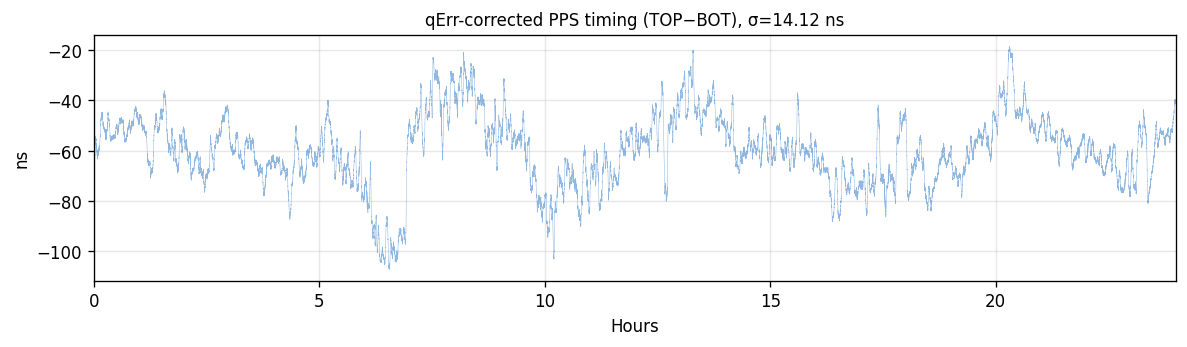

In [14]:
fig, ax = plt.subplots(figsize=(10, 3))
t = timing["hours"].values
v = timing["corr_ns"].values

# Decimate for plotting if > 50k points
if len(t) > 50000:
    step = len(t) // 50000
    t_plot, v_plot = t[::step], v[::step]
else:
    t_plot, v_plot = t, v

ax.plot(t_plot, v_plot, lw=0.3, alpha=0.6, color="#4488cc")
ax.set_xlim(0, FIXED_X_HOURS)
ax.set_xlabel("Hours")
ax.set_ylabel("ns")
ax.set_title(f"qErr-corrected PPS timing (TOP−BOT), σ={np.std(v):.2f} ns", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Full ADEV curve (multi-tau)

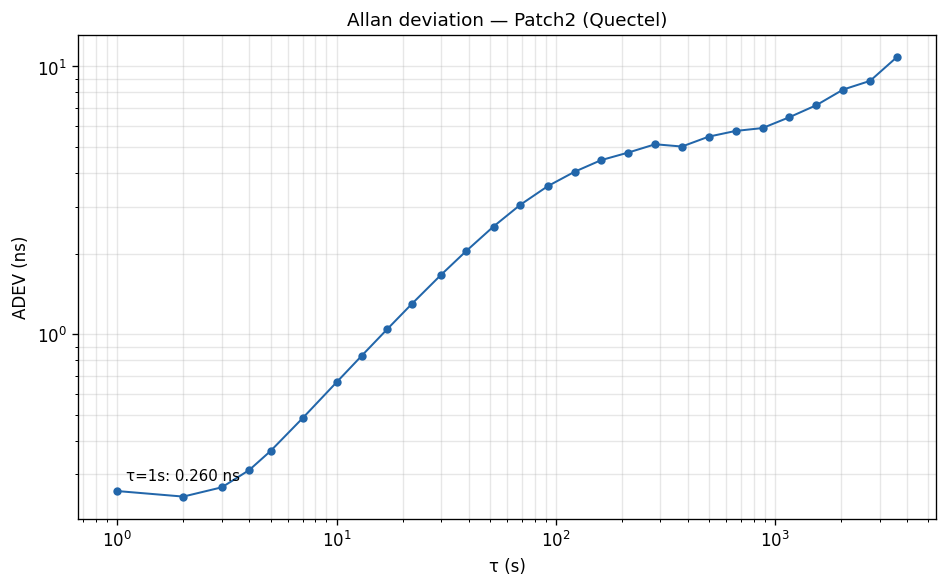

In [15]:
if HAS_ALLAN:
    freq_ns = timing["corr_ns"].values - timing["corr_ns"].mean()
    taus_req = np.logspace(0, np.log10(min(len(freq_ns) // 4, 3600)), 30)
    taus_out, ad, _, _ = allantools.adev(freq_ns, rate=1.0,
                                         data_type="freq", taus=taus_req)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.loglog(taus_out, ad, "o-", color="#2266aa", markersize=4, lw=1.2)
    ax.set_xlabel("τ (s)", fontsize=10)
    ax.set_ylabel("ADEV (ns)", fontsize=10)
    ax.set_title(f"Allan deviation — {ANTENNA}", fontsize=11)
    ax.grid(True, which="both", alpha=0.3)
    # Annotate τ=1s
    if len(taus_out) > 0:
        ax.annotate(f"τ=1s: {ad[0]:.3f} ns", xy=(taus_out[0], ad[0]),
                    fontsize=9, ha="left", va="bottom",
                    xytext=(5, 5), textcoords="offset points")
    plt.tight_layout()
    plt.show()
elif adev_pre is not None:
    overall = adev_pre[adev_pre["window_h"] < 0].sort_values("tau")
    if len(overall) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.loglog(overall["tau"], overall["adev_ns"], "o-",
                  color="#2266aa", markersize=4, lw=1.2)
        ax.set_xlabel("τ (s)")
        ax.set_ylabel("ADEV (ns)")
        ax.set_title(f"Allan deviation (pre-computed) — {ANTENNA}")
        ax.grid(True, which="both", alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No ADEV data available (install allantools or use pre-computed bundle)")

## 11. Score gauges

In [ ]:
summaries = {
    "cno_mean":      float(snr_rx["mean_cno"].mean()),
    "cmc_std":       float(rawx_rx["cmc_std_m"].median()),
    "adev_1s":       adev_overall if isinstance(adev_overall, float) else float(adev_overall),
    "lock_loss_pct": overall_pct,
    "sat_count":     float(snr_rx["sat_count"].mean()),
}
metric_values = [summaries["cno_mean"], summaries["cmc_std"], summaries["adev_1s"],
                 summaries["lock_loss_pct"], summaries["sat_count"]]

fig, axes = plt.subplots(len(METRICS), 1, figsize=(8, len(METRICS) * 0.8))
for i, (name, unit, lo, hi, log_scale) in enumerate(METRICS):
    ax = axes[i]
    val = metric_values[i]
    frac = fraction(val, lo, hi, log_scale)
    color = CMAP(frac)

    ax.barh(0, frac, height=0.6, color=color, ec="none")
    ax.barh(0, 1.0, height=0.6, color="#e8e8e8", ec="none", zorder=0)
    ax.barh(0, frac, height=0.6, color=color, ec="none", zorder=1)
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    label = f"{name}: {fmt_val(val)} {unit}"
    ax.text(-0.01, 0, label, ha="right", va="center", fontsize=9, fontweight="bold")

fig.suptitle(ANTENNA, fontsize=12, fontweight="bold", x=0.5, y=1.02)
plt.tight_layout()
plt.show()